In [3]:
import warnings 
warnings.filterwarnings('ignore')

In [4]:
import pandas as pd
import numpy as np
import math

# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc,roc_curve

In [5]:
df = pd.read_csv( 'Bank_Personal_Loan_Modelling.csv' )

In [6]:
df.head(5)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [7]:
# check for Missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [8]:
# study the Data Distribution for each attribute
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001AB7E25A208>,
      dtype=object)

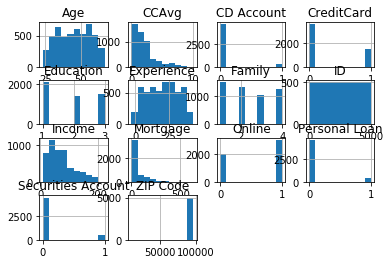

In [9]:
# Plot the distribution of variables using histogram
df.hist()

In [10]:
# 2.	Study the data distribution in each attribute, share your findings. 
# - The column ID can be ignored
# - Column Age, Experience, CCAvg and Mortgage are continuos variables
# - Column Education is a multiclass variable with values between 1 to 4
# - Column Security Account, CD Account, Online and Credit Card are Binary Class variables with values 0 and 1
# - ZIP Code is an Integer variable, but cannot be used as a numeric data - 
#            - as an alternate option can be converted to a string to be teated as a unique value
# - Personal Loan is the Target Variable , which is agaian a Binary Class variable with values 0 and 1

In [11]:
# convert ZIP Code from Numeric to String - to avoid being used in the model as a Numeric field
df['ZIP Code'] = df['ZIP Code'].astype(str)


In [12]:
# drop ID column
if 'ID' in df.columns:
    df.drop(['ID'], axis=1, inplace = True)

In [13]:
# Target Column Distribution
df.groupby(["Personal Loan"]).count().T

Personal Loan,0,1
Age,4520,480
Experience,4520,480
Income,4520,480
ZIP Code,4520,480
Family,4520,480
CCAvg,4520,480
Education,4520,480
Mortgage,4520,480
Securities Account,4520,480
CD Account,4520,480


In [14]:
# 3.	Target Column Distribution - Observations & Comments
# Distribution shows that only 480 out of 5000 rows are Non Defaulters i.e less than 10% data belongs to the Class 1
# Our Dominant Class , represented by Class 0 , represents the rows who did not opt for Personal Loan
# Our aim is to predict the Target Class 1 

In [15]:
# Prepare X and Y
X = df.drop("Personal Loan", axis=1)
y = df["Personal Loan"]

In [16]:
# 4.	Split the data into training and test set in the ratio of 70:30 respectively 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 7)

In [148]:
# 5.	Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a liability customer buying personal loans (25 points)
# 6.	Print the confusion matrix for all the above models (10 points)


 Confusion Matrix and Scores with BASE LR Model
[[3115  136]
 [  43  206]]
Accuracy Score 0.9488571428571428
Recall Score 0.6023391812865497
Precision Score 0.8273092369477911


C:\Users\Suchi\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\Suchi\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


Optimal Threshold for LR 0.38914674869906374
Confusion Matrix and Scores for Best LR Model :
[[3088  110]
 [  70  232]]
                  0
Accuracy   0.948571
Recall     0.678363
Precision  0.768212
F1         0.720497
roc-auc    0.828098


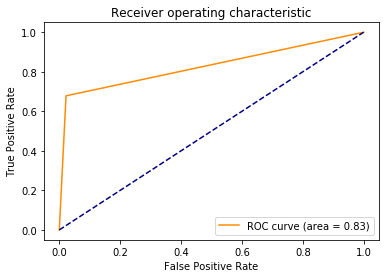

In [161]:
# Build Best Logistic Regression Model to Predict the likelihood of a liability customer buying personal loans
from sklearn.linear_model import LogisticRegression
LR_model = LogisticRegression()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 7)

cols = list(X.columns)
cols.remove('ZIP Code')
X_train = X_train[cols]
X_test = X_test[cols]

LR_model.fit(X_train,y_train)

# confusion matrix with basic Model
y_pred_class = LR_model.predict(X_train)
base_confusion = metrics.confusion_matrix(y_pred_class,y_train)
print (" Confusion Matrix and Scores with BASE LR Model")
print(base_confusion)
TP = base_confusion[1, 1]
TN = base_confusion[0, 0]
FP = base_confusion[0, 1]
FN = base_confusion[1, 0]
print("Accuracy Score" ,(TP + TN) / float(TP + TN + FP + FN))
print("Recall Score",TP / float(TP + FP))
print("Precision Score", TP / float(FN + TP))

# Find Optimal Threshold for Best Performance of Model
# Find Predicted Probabilities 
y_predictProb =  LR_model.predict_proba(X_train)
# Using the Predicted Probabilities , calculate the TPR, FPR and Thresholds 
fpr, tpr, thresholds = roc_curve(y_train, y_predictProb[::,1])
OPTIMAL_TH = 0
optimalF1 = 0
for th in thresholds:
    preds = np.where(LR_model.predict_proba(X_train)[:,1] > th, 1, 0)
    f1Score = f1_score(y_train, preds)
    if(optimalF1 < f1Score):
        optimalF1 = f1Score
        OPTIMAL_TH = th
print("Optimal Threshold for LR", OPTIMAL_TH)
# Using Optimal TH , calculate accuracy scores and ROC-AUC curve for LR Model
LR_Train_YPreds = np.where(LR_model.predict_proba(X_train)[:,1] > OPTIMAL_TH, 1, 0)
LR_Train_Accuracy = accuracy_score(y_train, LR_Train_YPreds)
LR_Train_Recall = recall_score(y_train, LR_Train_YPreds)
LR_Train_Precision = precision_score(y_train, LR_Train_YPreds)
LR_Train_F1score = f1_score(y_train, LR_Train_YPreds)
fpr, tpr, thresholds = roc_curve(y_train, LR_Train_YPreds)
LR_Train_roc_auc = auc(fpr, tpr)

# Display Results
score_result = pd.DataFrame(data=[LR_Train_Accuracy, LR_Train_Recall,
                   LR_Train_Precision, LR_Train_F1score, LR_Train_roc_auc],                     
             index=["Accuracy", "Recall", "Precision","F1", "roc-auc"])

# Using Optimal TH , calculate confusion matrix for Best Model
# predict Class = 1 if the predicted probability is greater than Optimal Threshold
from sklearn.preprocessing import binarize
# it will return 1 for all values above Thershold and 0 otherwise
y_pred_prob = LR_model.predict_proba(X_train)
y_pred_class = binarize(y_pred_prob, OPTIMAL_TH)
y_pred_class = y_pred_class[:,1]
# new confusion matrix
print("Confusion Matrix and Scores for Best LR Model :")
print(metrics.confusion_matrix(y_pred_class,y_train))
print(score_result)

plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % LR_Train_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

# Calculate Scores for TEST Data
LR_model.fit(X_test,y_test)
LR_Test_YPreds = np.where(LR_model.predict_proba(X_test)[:,1] > OPTIMAL_TH, 1, 0)
LR_Test_Accuracy = accuracy_score(y_test, LR_Test_YPreds)
LR_Test_Recall = recall_score(y_test, LR_Test_YPreds)
LR_Test_Precision = precision_score(y_test, LR_Test_YPreds)
LR_Test_F1score = f1_score(y_test, LR_Test_YPreds)
LR_Test_fpr, LR_Test_tpr, thresholds = roc_curve(y_test, LR_Test_YPreds)
LR_Test_roc_auc = auc(LR_Test_fpr, LR_Test_tpr)

 Confusion Matrix and Scores with BASE KNN Model
[[3150   98]
 [   8  244]]
Accuracy Score 0.9697142857142858
Recall Score 0.7134502923976608
Precision Score 0.9682539682539683

The optimal no. of neighbors is 3
Confusion Matrix and Scores for Best KNN Model :
[[3152   75]
 [   6  267]]
                  0
Accuracy   0.976857
Recall     0.780702
Precision  0.978022
F1         0.868293
roc-auc    0.889401


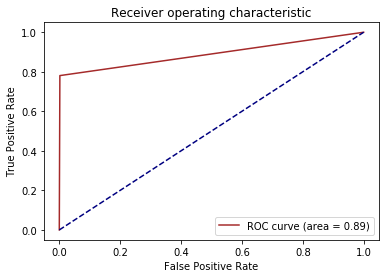

In [162]:
# Build Best KNN Classification Model to Predict the likelihood of a liability customer buying personal loans
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import zscore

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 7)

cols = list(X.columns)
cols.remove('ZIP Code')
X_train = X_train[cols].apply(zscore)  # convert all attributes to Z scale 
X_test = X_test[cols].apply(zscore)  # convert all attributes to Z scale 

KNN_model = KNeighborsClassifier()
KNN_model.fit(X_train, y_train)

# confusion matrix with basic Model
y_pred_class = KNN_model.predict(X_train)
base_confusion = metrics.confusion_matrix(y_pred_class,y_train)
print (" Confusion Matrix and Scores with BASE KNN Model")
print(base_confusion)
TP = base_confusion[1, 1]
TN = base_confusion[0, 0]
FP = base_confusion[0, 1]
FN = base_confusion[1, 0]
print("Accuracy Score" ,(TP + TN) / float(TP + TN + FP + FN))
print("Recall Score",TP / float(TP + FP))
print("Precision Score", TP / float(FN + TP))
print("")

# Find Optimal value of K - no. of neighbors based on Minimum MSE
k_list = list(range(2, 21))
MSE_list = []
for k in k_list :
        model = KNeighborsClassifier(n_neighbors= k)
        model.fit(X_train, y_train)
        YPreds = model.predict(X_train)
        MSE = 1 - accuracy_score(y_train, YPreds)
        MSE_list.append(MSE)

# Find Optimal K based on Minimum MSE
OPTIMAL_K = k_list[MSE_list.index(min(MSE_list))]
print("The optimal no. of neighbors is",OPTIMAL_K)

# Using Optimal K , calculate accuracy scores and ROC-AUC curve for KNN Model
KNN_model = KNeighborsClassifier(n_neighbors= OPTIMAL_K)
KNN_model.fit(X_train, y_train)

KNN_Train_YPreds = KNN_model.predict(X_train)
KNN_Train_Accuracy = accuracy_score(y_train, KNN_Train_YPreds)
KNN_Train_Recall = recall_score(y_train, KNN_Train_YPreds)
KNN_Train_Precision = precision_score(y_train, KNN_Train_YPreds)
KNN_Train_F1score = f1_score(y_train, KNN_Train_YPreds)
fpr, tpr, thresholds = roc_curve(y_train, KNN_Train_YPreds)
KNN_Train_roc_auc = auc(fpr, tpr)

# Display Results
score_result = pd.DataFrame(data=[KNN_Train_Accuracy, KNN_Train_Recall,
                   KNN_Train_Precision, KNN_Train_F1score, KNN_Train_roc_auc],                     
             index=["Accuracy", "Recall", "Precision","F1", "roc-auc"])

print("Confusion Matrix and Scores for Best KNN Model :")
print(metrics.confusion_matrix(KNN_Train_YPreds,y_train))
print(score_result)

plt.plot(fpr, tpr, color='brown', label='ROC curve (area = %0.2f)' % KNN_Train_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

# Calculate Scores for TEST Data
KNN_model.fit(X_test,y_test)
KNN_Test_YPreds = KNN_model.predict(X_test)
KNN_Test_Accuracy = accuracy_score(y_test, KNN_Test_YPreds)
KNN_Test_Recall = recall_score(y_test, KNN_Test_YPreds)
KNN_Test_Precision = precision_score(y_test, KNN_Test_YPreds)
KNN_Test_F1score = f1_score(y_test, KNN_Test_YPreds)
KNN_Test_fpr, KNN_Test_tpr, thresholds = roc_curve(y_test, KNN_Test_YPreds)
KNN_Test_roc_auc = auc(KNN_Test_fpr, KNN_Test_tpr)

 Confusion Matrix and Scores with BASE Naive Bayes Model
[[2896  150]
 [ 262  192]]
Accuracy Score 0.8822857142857143
Recall Score 0.5614035087719298
Precision Score 0.42290748898678415



C:\Users\Suchi\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\Suchi\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


Optimal Threshold for Naive Bayes 0.054638035081922366
Confusion Matrix and Scores for Best Naive Bayes Model :
[[2750   64]
 [ 408  278]]
                  0
Accuracy   0.865143
Recall     0.812865
Precision  0.405248
F1         0.540856
roc-auc    0.841835


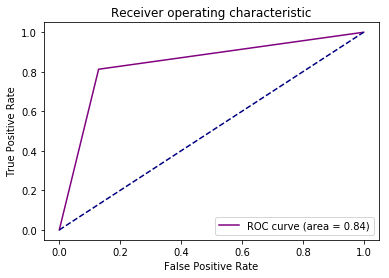

In [163]:
# Build Best Naive Bayes Classification Model to Predict the likelihood of a liability customer buying personal loans
from sklearn.naive_bayes import GaussianNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 7)

cols = list(X.columns)
cols.remove('ZIP Code')
X_train = X_train[cols]
X_test = X_test[cols] 

NB_model = GaussianNB()
NB_model.fit(X_train, y_train)

# confusion matrix with basic Model
y_pred_class = NB_model.predict(X_train)
base_confusion = metrics.confusion_matrix(y_pred_class,y_train)
print (" Confusion Matrix and Scores with BASE Naive Bayes Model")
print(base_confusion)
TP = base_confusion[1, 1]
TN = base_confusion[0, 0]
FP = base_confusion[0, 1]
FN = base_confusion[1, 0]
print("Accuracy Score" ,(TP + TN) / float(TP + TN + FP + FN))
print("Recall Score",TP / float(TP + FP))
print("Precision Score", TP / float(FN + TP))
print("")

# Find Optimal Threshold for Best Performance of Model
# Find Predicted Probabilities 
y_predictProb =  NB_model.predict_proba(X_train)
# Using the Predicted Probabilities , calculate the TPR, FPR and Thresholds 
fpr, tpr, thresholds = roc_curve(y_train, y_predictProb[::,1])
OPTIMAL_TH = 0
optimalF1 = 0
for th in thresholds:
    preds = np.where(NB_model.predict_proba(X_train)[:,1] > th, 1, 0)
    f1Score = f1_score(y_train, preds)
    if(optimalF1 < f1Score):
        optimalF1 = f1Score
        OPTIMAL_TH = th
print("Optimal Threshold for Naive Bayes", OPTIMAL_TH)
# Using Optimal TH , calculate accuracy scores and ROC-AUC curve for Naive Bayes Model
NB_Train_YPreds = np.where(NB_model.predict_proba(X_train)[:,1] > OPTIMAL_TH, 1, 0)
NB_Train_Accuracy = accuracy_score(y_train, NB_Train_YPreds)
NB_Train_Recall = recall_score(y_train, NB_Train_YPreds)
NB_Train_Precision = precision_score(y_train, NB_Train_YPreds)
NB_Train_F1score = f1_score(y_train, NB_Train_YPreds)
fpr, tpr, thresholds = roc_curve(y_train, NB_Train_YPreds)
NB_Train_roc_auc = auc(fpr, tpr)

# Display Results
score_result = pd.DataFrame(data=[NB_Train_Accuracy, NB_Train_Recall,
                   NB_Train_Precision, NB_Train_F1score, NB_Train_roc_auc],                     
             index=["Accuracy", "Recall", "Precision","F1", "roc-auc"])

# Using Optimal TH , calculate confusion matrix for Best Model
# predict Class = 1 if the predicted probability is greater than Optimal Threshold
from sklearn.preprocessing import binarize
# it will return 1 for all values above Thershold and 0 otherwise
y_pred_prob = NB_model.predict_proba(X_train)
y_pred_class = binarize(y_pred_prob, OPTIMAL_TH)
y_pred_class = y_pred_class[:,1]
# new confusion matrix
print("Confusion Matrix and Scores for Best Naive Bayes Model :")
print(metrics.confusion_matrix(y_pred_class,y_train))
print(score_result)

plt.plot(fpr, tpr, color='purple', label='ROC curve (area = %0.2f)' % NB_Train_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

# Calculate Scores for TEST Data
NB_model.fit(X_test,y_test)
NB_Test_YPreds = np.where(NB_model.predict_proba(X_test)[:,1] > OPTIMAL_TH, 1, 0)
NB_Test_Accuracy = accuracy_score(y_test, NB_Test_YPreds)
NB_Test_Recall = recall_score(y_test, NB_Test_YPreds)
NB_Test_Precision = precision_score(y_test, NB_Test_YPreds)
NB_Test_F1score = f1_score(y_test, NB_Test_YPreds)
NB_Test_fpr, NB_Test_tpr, thresholds = roc_curve(y_test, NB_Test_YPreds)
NB_Test_roc_auc = auc(NB_Test_fpr, NB_Test_tpr)

In [149]:
# 7.	Give your reasoning on which is the best model in this case and why it performs better? (10 points)

           LR Test Results  KNN Test Results  NB Test Results
Accuracy          0.953333          0.974667         0.862000
Recall            0.673913          0.753623         0.876812
Precision         0.788136          0.962963         0.389068
F1_score          0.726562          0.845528         0.538976
roc-auc           0.827779          0.875343         0.868655


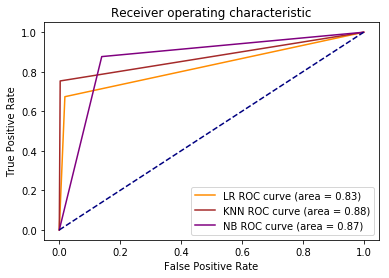

In [166]:
# Display the Test Validation Results for all the three Models
resultsDf = pd.DataFrame( index=["Accuracy", "Recall", "Precision", "F1_score", "roc-auc"])

LR_testResults=[LR_Test_Accuracy, LR_Test_Recall, LR_Test_Precision, LR_Test_F1score,LR_Test_roc_auc]
KNN_testResults=[KNN_Test_Accuracy, KNN_Test_Recall, KNN_Test_Precision, KNN_Test_F1score,KNN_Test_roc_auc]
NB_testResults=[NB_Test_Accuracy, NB_Test_Recall, NB_Test_Precision, NB_Test_F1score,NB_Test_roc_auc]

# Concatenate Train and Test results to resultsDf
resultsDf['LR Test Results'] = LR_testResults
resultsDf['KNN Test Results'] = KNN_testResults
resultsDf['NB Test Results'] = NB_testResults

print(resultsDf)

plt.plot(LR_Test_fpr, LR_Test_tpr, color='darkorange', label='LR ROC curve (area = %0.2f)' % LR_Test_roc_auc)
plt.plot(KNN_Test_fpr, KNN_Test_tpr, color='brown', label='KNN ROC curve (area = %0.2f)' % KNN_Test_roc_auc)
plt.plot(NB_Test_fpr, NB_Test_tpr, color='purple', label='NB ROC curve (area = %0.2f)' % NB_Test_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

In [ ]:
# Conclusions
# - Though the ReCall Score is higher for Naive Bayes Mode, the Precision Score is highest for KNN Model
# - We look at the F1 score which is Harmonic mean of Precision and ReCall scores
# - Based on F1-Score and area under AUC-ROC curve , the KNN - Classifier Model seems to perform BEST for the given set of Data
# KNN tends to perform better in this case because :
# - KNN tends to perform well when we have many rows and fewer dimensions
# - KNN performs better when we have non overlapping classes which was the case here for many of the attributes as displayed by the attribute histogram